### 3.1-3.3 Simplified Attention Mechenism

In [8]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

1. 计算注意力分数

In [9]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
for i, xi in enumerate(inputs):
    attn_scores_2[i] = torch.dot(xi, query)
print(attn_scores_2)


tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


2. 归一化，计算注意力权重

In [10]:
# 方式一：
attn_scores_2_tmp = attn_scores_2 / attn_scores_2.sum()
print(attn_scores_2_tmp)
print(attn_scores_2_tmp.sum())

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
tensor(1.0000)


In [11]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

有三种softmax, `nn.Softmax`, `F.softmax` 和 `torch.softmax`

| 写法              | 类型         | 是否 Module | 推荐场景         |
| --------------- | ---------- | --------- | ------------ |
| `nn.Softmax`    | 层          | ✅         | 放进模型结构       |
| `F.softmax`     | functional | ❌         | forward 计算 ⭐ |
| `torch.softmax` | tensor op  | ❌         | 底层算子 ⭐⭐      |

关系：     
nn.Softmax.forward   
        ↓   
F.softmax  
        ↓  
torch.softmax  
        ↓  
C++ / CUDA kernel  

In [12]:
# 方式二：softmax归一化，可以确保每项都大于0
attn_weight_2_tmp = softmax_naive(attn_scores_2)
print(attn_weight_2_tmp)
print(attn_weight_2_tmp.sum())

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor(1.)


In [13]:
# 方式二正规版
attn_weight_2 = torch.softmax(attn_scores_2, dim=0)
print(attn_weight_2)
print(attn_weight_2.sum())

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor(1.)


3. 计算context vector

In [14]:
# 单个context_vector
context_vector_2 = torch.empty(query.shape)
print(query.shape)
for i, x_i in enumerate(inputs):
    print(x_i, attn_weight_2[i])
    context_vector_2 += x_i  *  attn_weight_2[i]
print(context_vector_2)

torch.Size([3])
tensor([0.4300, 0.1500, 0.8900]) tensor(0.1385)
tensor([0.5500, 0.8700, 0.6600]) tensor(0.2379)
tensor([0.5700, 0.8500, 0.6400]) tensor(0.2333)
tensor([0.2200, 0.5800, 0.3300]) tensor(0.1240)
tensor([0.7700, 0.2500, 0.1000]) tensor(0.1082)
tensor([0.0500, 0.8000, 0.5500]) tensor(0.1581)
tensor([0.4419, 0.6515, 0.5683])


拓展到多个元素

In [15]:
print(inputs)

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])


In [16]:
# 多个元素的注意力分数
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [17]:
# 多个元素的注意力权重
attn_weight = [torch.softmax(attn_scores_i,dim=0) for attn_scores_i in attn_scores]
print(attn_weight)

attn_weights = torch.softmax(attn_scores, dim=-1) # 通过设置 dim=-1，我们指示 softmax 函数沿 attn_scores 张量的最后一个维度应用归一化。
print(attn_weights)
sums = [x.sum() for x in attn_weights]
print(sums) #验证是行上的归一化

[tensor([0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452]), tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581]), tensor([0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565]), tensor([0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720]), tensor([0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295]), tensor([0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896])]
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])
[tensor(1.0000), tensor(1.), tensor(1.0000), tensor(1.), tensor(1.), tensor(1.)]


In [18]:
# 多个元素的上下文向量
context_vector = attn_weights @ inputs
print(context_vector)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


### 3.4 Implementing self-attention with trainable weights

In [19]:
x_2 = inputs[1]         # <— 第二个输入元素
d_in = inputs.shape[1]  # <— 输入嵌入的大小，d=3. 0是行，元素数量；1是列，元素属性数量
d_out = 2               # <— 输出嵌入的大小，d_out=2
print(inputs)
print(x_2)
print(inputs.shape)

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])
tensor([0.5500, 0.8700, 0.6600])
torch.Size([6, 3])


```class torch.nn.parameter.Parameter(data=None, requires_grad=True)```

https://www.geeksforgeeks.org/deep-learning/understanding-torchnnparameter/

`torch.nn.Parameter` 是 torch.Tensor 的一个子类，专门用于持有在训练模型时需要考虑的参数。当一个张量被包裹在 `torch.nn.Parameter` 中时，它会自动成为模型参数的一部分，并且在训练过程中应用反向传播时会被更新，并可以通过使用 `parameters` 迭代器来访问。

In [20]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
print(W_query)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])


In [21]:
# 单个元素的向量
print(x_2)
query_2 = x_2 @ W_query # 1*3, 3*2 = 1*2
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)

tensor([0.5500, 0.8700, 0.6600])
tensor([0.4306, 1.4551])


In [22]:
# 所有元素的向量
keys = inputs @ W_key # 6*3, 3*2
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


### 计算注意力分数

In [23]:
# x_2 对 x2 的注意力分数
print(query_2)
print(key_2)
attn_score_22 = query_2.dot(key_2) # <— 记住 Python 的索引从 0 开始。 # 1*2， 1*2
print(attn_score_22)

tensor([0.4306, 1.4551])
tensor([0.4433, 1.1419])
tensor(1.8524)


In [24]:
# x_2对多个元素的注意力分数
# 注意是query查询变量分别乘以所有key变量
attn_score_2 = query_2 @ keys.T # 1*2, 2*6
print(attn_score_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


### 计算注意力权重

从注意力分数过渡到注意力权重，但是需要先缩放，将注意力分数除以键的嵌入维度的平方根

为什么？

** 点积的数值规模会随着维度增长而变大 **

除以 $√dₖ$ 可以让 attention score 的尺度：   
* 不随 embedding 维度增长
* 保持稳定分布
* softmax 工作在健康区间

否则： attention 变成 one-hot

模型行为：  
只关注一个 token
失去 soft attention

In [25]:
d_k = keys.shape[-1]
attn_weight_2 = torch.softmax(attn_score_2 / d_k**0.5, dim=-1)
print(attn_weight_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [26]:
context_vec_2 = attn_weight_2 @ values # 1*6, 6*2
print(context_vec_2)

tensor([0.3061, 0.8210])


In [27]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        # 3*2
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))
    
    def forward(self, x):
        queries = x @ self.W_query
        keys   = x @ self.W_key # 6,2
        values = x @ self.W_value
        #w2 = querys[1] @ keys.T
        attn_scores = queries @ keys.T # 6*2， 2*6
        d_k = keys.shape[-1]
        attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
        context_vector = attn_weights @ values
        return context_vector

In [28]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


我们可以通过利用 PyTorch 的 `nn.Linear` 层来进一步改进 `SelfAttention_v1` 的实现   
当偏置单元被禁用时，它能有效地执行矩阵乘法；  
此外，使用 `nn.Linear` 而不是手动实现 `nn.Parameter(torch.rand(...))` 的好处是 `nn.Linear` 具有优化的权重初始化方案，有助于更稳定和有效的模型训练

`class torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)`

https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html

对输入数据应用仿射线性变换：$y=xA^T + b$ . $A$, $b$ 为内部成员变量
```
>>> m = nn.Linear(20, 30)  
>>> input = torch.randn(128, 20)  
>>> output = m(input)  
>>> print(output.size())  
torch.Size([128, 30])
```

In [29]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        # print(f"W_query.weight= {self.W_query.weight.T}")
        # print(f"W_key.weight= {self.W_key.weight.T}")
        # print(f"W_value.weight= {self.W_value.weight.T}")

    def forward(self, x):
        keys    = self.W_key(x)  # Linear 类型不能再用 @
        values  = self.W_value(x)
        queries = self.W_query(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        context_vec = attn_weights @ values
        return context_vec
    
    def get_weights(self):
        return self.W_query.weight.T, self.W_key.weight.T, self.W_value.weight.T

In [30]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
con_vec_v2 = sa_v2(inputs)
print(con_vec_v2)

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


##### 练习 3.1 比较 SelfAttention_v1 和 SelfAttention_v2

请注意，`SelfAttention_v2` 中的 `nn.Linear` 使用了与 `SelfAttention_v1` 中使用的 `nn.Parameter(torch.rand(d_in, d_out))` 不同的权重初始化方案，这导致两种机制产生不同的结果。要检查这两种实现（`SelfAttention_v1` 和 `SelfAttention_v2`）在其他方面是否相似，我们可以将权重矩阵从 `SelfAttention_v2` 对象转移到 `SelfAttention_v1`，使得这两个对象随后产生相同的结果。

你的任务是将 `SelfAttention_v2` 实例的权重正确分配给 `SelfAttention_v1` 实例。为此，你需要理解这两个版本中权重之间的关系。（提示：`nn.Linear` 以转置形式存储权重矩阵。）赋值之后，你应该观察到两个实例产生相同的输出。

In [31]:
import torch.nn as nn
class SelfAttention_v11(nn.Module):
    def __init__(self, d_in, d_out, w_query, w_key, w_value):
        super().__init__()
        # 3*2
        self.W_query = w_query
        self.W_key = w_key
        self.W_value = w_value
        '''
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))
        '''
    
    def forward(self, x):
        queries = x @ self.W_query
        keys   = x @ self.W_key # 6,2
        values = x @ self.W_value
        #w2 = querys[1] @ keys.T
        attn_scores = queries @ keys.T # 6*2， 2*6
        d_k = keys.shape[-1]
        attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
        context_vector = attn_weights @ values
        return context_vector

In [32]:
w_query, w_key, w_value = sa_v2.get_weights()
sa_v11 = SelfAttention_v11(d_in, d_out, w_query, w_key, w_value)
con_vec_v1 = sa_v11(inputs)
print(con_vec_v1)
print(con_vec_v2)

print(con_vec_v2 == con_vec_v1)

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)
tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)
tensor([[True, True],
        [True, True],
        [True, True],
        [True, True],
        [True, True],
        [True, True]])


## 3.5 Casual attention/masked attention

### Hiding future words

Attention scores(unnormalized)    
-> 1) Apply softmax  -> Attention weights (normalized)  
-> 2) Mask with 0’s above diagonal -> Masked attention scores(unnormalized)  
-> 3) Normalize rows -> Masked attention weights(normalized)  

In [33]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [34]:
x = torch.arange(1,10).reshape(3,3) #  arange() can create the 1D tensor of zero or integers or floating-point numbers between start and end-1

yu = torch.triu(x) # in and upper triangle
print(yu)
yl = torch.tril(x) # in and lower triangle
print(yl)

tensor([[1, 2, 3],
        [0, 5, 6],
        [0, 0, 9]])
tensor([[1, 0, 0],
        [4, 5, 0],
        [7, 8, 9]])


In [35]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

mask = torch.tril(torch.ones(attn_weights.shape[0], attn_weights.shape[-1]))
masked_attn_scores = attn_weights.mul(mask)
print(masked_attn_scores)
row_sum = masked_attn_scores.sum(dim=1, keepdim=True) # dim=0按列求行或=1按行求列的sum，keepdim能保持结果为一行（求行sum）或一列(求列sum)
print(row_sum)
attn_weights = masked_attn_scores / row_sum
print(attn_weights)



tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)
tensor([[0.1921],
        [0.3700],
        [0.5357],
        [0.6775],
        [0.8415],
        [1.0000]], grad_fn=<SumBackward1>)
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [36]:
test = torch.ones(attn_weights.shape[0], attn_weights.shape[-1])
test = torch.tril(test)
print(test)


tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


存在另一种简化的方式：

Attention scores (unnormalized)  
-> 1) Mask with −∞ above diagonal -> Masked attention scores (unnormalized)  
-> 2) Apply softmax -> Masked attention weights (normalized)

softmax 函数将其输入转换为概率分布。当一行中存在负无穷大值（$-\infty$）时，softmax 函数将它们视为零概率。（在数学上，这是因为 $e^{-\infty}$ 趋近于 0。）

In [37]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
context_length = attn_scores.shape[0]
mask = torch.triu(torch.ones(context_length,context_length, dtype=torch.bool), diagonal=1)
masked_attn_scores = attn_scores.masked_fill(mask, -torch.inf)
#print(masked_attn_scores)
attn_weights = torch.softmax(masked_attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


### Dropout

深度学习中的 Dropout 是一种在训练期间随机忽略（有效地“丢弃”）选定隐藏层单元的技术。这种方法通过确保模型不会过度依赖于任何特定的隐藏层单元集来帮助防止过拟合。需要强调的是，dropout 仅在训练期间使用，并在之后被禁用。

注意力机制中的 dropout 通常在两个特定时间应用：在计算出注意力权重之后，或者在将注意力权重应用于值向量之后。这里使用第一种：计算出注意力权重后。

In [38]:
torch.manual_seed(123)
dropout = nn.Dropout(0.5) # dropout 50% words randomly
example = torch.ones(6,6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


**为什么元素从1变成2(翻倍)？**   
当以 50% 的比率将 dropout 应用于注意力权重矩阵时，矩阵中一半的元素被随机设置为零。为了补偿活跃元素的减少，矩阵中剩余元素的值被放大 1/0.5 = 2 倍。这种缩放对于维持注意力的整体平衡至关重要

In [39]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


### Batch

```torch.stack(tensors, dim=0, *, out=None) → Tensor```

连接一串张量，组成新维度
Concatenates a sequence of tensors along a new dimension.

In [40]:
batch = torch.stack((inputs, inputs), dim=0) # 两个[6,3]输入组成[2, 6, 3]张量
print(batch.shape)

torch.Size([2, 6, 3])


高维tensor矩阵@乘只看最低2维 `[..., M, N]`   
维度不一致会广播补齐;   
维度一致必须batch相同   

| 操作      | 规则            |
| ------- | ------------- |
| 2D @ 3D | 左边广播 batch    |
| 3D @ 2D | 右边广播 batch    |
| 3D @ 3D | batch 对 batch |


不要用 .T 乱转高维，`K.T` 只对2维有意义。   
高维使用:  `Tensor.transpose(dim0, dim1)` 或者 `torch.transpose(input, dim0, dim1)`    

```K.transpose(-1,-2)```

In [41]:
print(sa_v2.W_key.weight.T.shape)
# batch[2][6][3] * W_query[3][2]
# W_query被广播成[2][6][3]，乘法两边各2层，每层[6][3]*[3][2]。结果[2][6][2]
queries = sa_v2.W_query(batch) 
keys = sa_v2.W_key(batch)
values = sa_v2.W_value(batch)
test_attn_scores = queries @ keys.transpose(-1,-2)     # [2][6][2] * [2][2][6]
print(test_attn_scores.shape)

torch.Size([3, 2])
torch.Size([2, 6, 6])


In [42]:
print(torch.triu(torch.ones(6, 6), diagonal=1))

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


```register_buffer(name, tensor, persistent=True)```

添加一个名为name的tensor到buffer中

### Casual attention class

In [43]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout_rate, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout_rate) # <— 与之前的 SelfAttention_v1 类相比，我们添加了一个 dropout 层。
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
            diagonal=1)
        ) # <— register_buffer 调用也是一个新增内容（后续文本中提供了更多信息）。

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # <— 我们转置维度 1 和 2，将批次（batch）维度保留在第一个位置（0）。
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        ) # <— 在 PyTorch 中，带有尾随下划线的操作是就地执行的，避免了不必要的内存复制。
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec

增加 `self.register_buffer()` 调用可以在大模型中调用该 `CausalAttention` 类时,确保buffer和模型一起自动移动到适当的设备cpu/gpu，不需要手动设置

In [60]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)
print("context_vecs:", context_vecs)

context_vecs.shape: torch.Size([2, 6, 2])
context_vecs: tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


## 3.6 multi-head attention

### Stack multi single-head attention layers

In [70]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = [
            CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) for _ in range(num_heads)
            ]

    def forward(self, x):
        # 沿着embedding维度拼接，(6,2) + (6,2) -> (6,4)
        return torch.cat([head(x)  for head in self.heads], dim=-1)


对于连接n个3维数据[a,b,c]:     
dim=0:把n个2维矩阵[i,b1,c1]和[i,b2,c2]顺序连接，得到[na,b,c];  
dim=1:依次连接到前一组矩阵的后面行，得到[a,nb,c]  
dim=2:依次连接到前一组矩阵的后面列，得到[a,b,nc]  

几何来看，dim=0/1/2 就是按z轴摞起来/y轴放下面/x轴放右面放置长方体

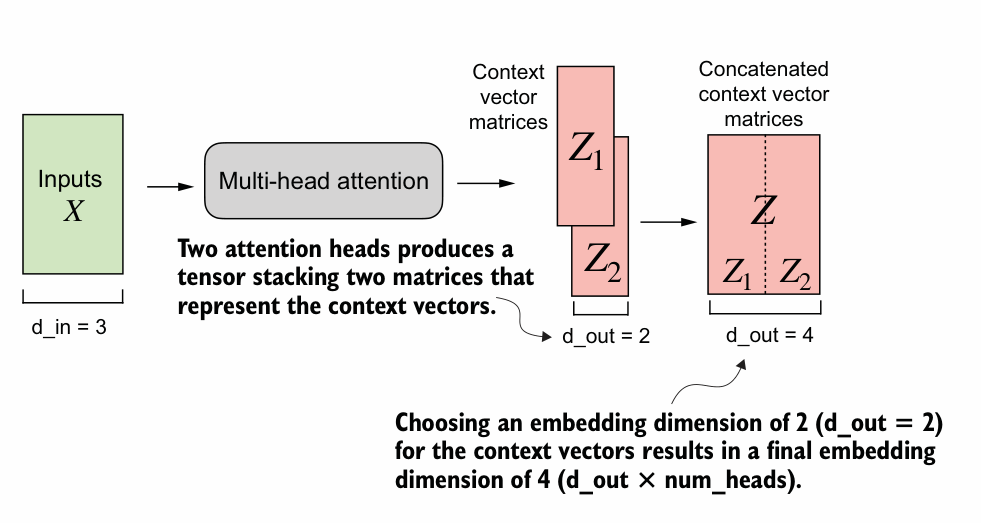

In [ ]:
torch.manual_seed(123)
heads = MultiHeadAttentionWrapper(d_in, d_out, batch.shape[1], 0.0, 2)
cxt_vecs = heads(batch) # 2个头，每个头[2,6,3]的输入，得到[2,6,2]的输出。经过连接得到[2,6,4]
print(cxt_vecs.shape)
print(cxt_vecs)

torch.Size([2, 6, 4])
tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)


In [64]:
torch.manual_seed(123)
context_length = batch.shape[1] # 这是词元的数量
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


得到的 `context_vecs` 张量的第一个维度是 2，因为我们有两个输入文本（输入文本是重复的，这就是为什么上下文向量在这些文本中完全相同的原因）。第二个维度指的是每个输入中的 6 个词元。第三个维度是指每个词元的四维嵌入。

#### 练习 3.2 返回二维嵌入向量    
更改 `MultiHeadAttentionWrapper(..., num_heads=2)` 调用的输入参数，使得输出的上下文向量是二维的而不是四维的，同时保持设置 `num_heads=2`。提示：您不必修改类实现；您只需要更改其中一个输入参数即可。

> “最终维度是 4” 指的是 embedding size，不是 tensor 的维数。

In [67]:
class MultiHeadAttentionWrapper_prac(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = [
            CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) for _ in range(num_heads)
            ]

    def forward(self, x):
        return torch.cat([head(x)  for head in self.heads], dim=-1)


In [69]:
torch.manual_seed(123)
context_length = batch.shape[1] # 这是词元的数量
d_in, d_out = 3, 1
mha = MultiHeadAttentionWrapper_prac(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]],

        [[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


### Implementing multi-head attention with weight splits

In [80]:
mask = torch.triu(torch.ones(5,5), diagonal=1)
sm_size = 3
mask = mask[:sm_size, :sm_size]
print(mask)

tensor([[0., 1., 1.],
        [0., 0., 1.],
        [0., 0., 0.]])


In [105]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert(d_out % num_heads == 0), "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # 各个头平分维度
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out) # 用线性层结合头输出
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1) # context_length是最大长度，用到时根据需要裁剪
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # 下面3个tensor形状 (b, num_tokens, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # 从        (b, num_tokens, d_out)
        # 分割成    (b, num_tokens, num_heads, head_dim)
        # 转置成    (b, num_heads, num_tokens, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        # 为每个头计算点积
        # (b, num_heads, num_tokens, head_dim) @ (b, num_heads, head_dim, num_tokens)
        # = (b, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3) # transpose转置为了维度[..., m, n]匹配

        # 掩码填充注意力分数
        # 最后两个维度都是num_tokens， 和前面一致
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        # 归一化并dropout注意力权重
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # (b, num_tokens, n_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1,2)
        # 结合多个头, self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )

        # 添加可选线性映射
        context_vec = self.out_proj(context_vec)
        return context_vec

`Tensor.contiguous(memory_format=torch.contiguous_format)` → Tensor

Returns a contiguous in memory tensor containing the same data as self tensor. If self tensor is already in the specified memory format, this function returns the self tensor.   
返回一个连续存储在内存中的张量，包含与self张量相同的数据。如果self张量已经处于指定的内存格式，则此函数返回self张量。

In [106]:
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573], # <— 此张量的形状是 (b, num_heads, num_tokens, head_dim) = (1, 2, 3, 4)。
                    [0.8993, 0.0390, 0.9268, 0.7388],
                    [0.7179, 0.7058, 0.9156, 0.4340]],

                   [[0.0772, 0.3565, 0.1479, 0.5331],
                    [0.4066, 0.2318, 0.4545, 0.9737],
                    [0.4606, 0.5159, 0.4220, 0.5786]]]])

In [107]:
## (b, num_heads, num_tokens, head_dim) @ (b, num_heads, head_dim， num_tokens)
print(a @ a.transpose(2,3))

tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


In [108]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


#### 练习 3.3 初始化 GPT-2 规模的注意力模块

使用 `MultiHeadAttention` 类，初始化一个多头注意力模块，其注意力头数与最小的 GPT-2 模型相同（12 个注意力头）。还要确保你使用了与 GPT-2 类似的相应输入和输出嵌入大小（768 维）。请注意，最小的 GPT-2 模型支持 1,024 个词元的上下文长度。

In [110]:
context_length = 1024
d_in, d_out = 168, 168
num_heads = 12
mha =  MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads)
